In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/dengue_19_20_21.csv')
df['Date'] = pd.to_datetime(df['Date'])
print(df.shape, df.dtypes, df.isnull().sum())

(936, 16) Province                  object
District                  object
Dengue_Cases               int64
Month                      int64
Year                       int64
Date              datetime64[ns]
City                      object
Temp_Max_Mean            float64
Temp_Min_Mean            float64
Temp_Mean                float64
Precipitation            float64
Rain_Sum                 float64
Humidity_Proxy           float64
Windspeed_Max            float64
Latitude                 float64
Longitude                float64
dtype: object Province          0
District          0
Dengue_Cases      0
Month             0
Year              0
Date              0
City              0
Temp_Max_Mean     0
Temp_Min_Mean     0
Temp_Mean         0
Precipitation     0
Rain_Sum          0
Humidity_Proxy    0
Windspeed_Max     0
Latitude          0
Longitude         0
dtype: int64


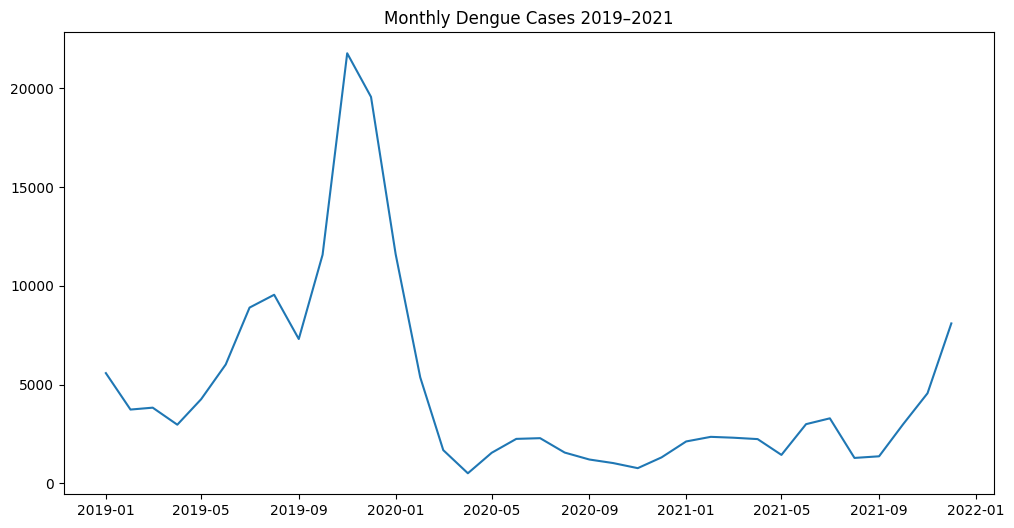

In [14]:
monthly = df.groupby('Date')['Dengue_Cases'].sum().reset_index()
plt.figure(figsize=(12,6))
plt.plot(monthly['Date'],monthly['Dengue_Cases'])
plt.title('Monthly Dengue Cases 2019–2021')
plt.savefig('../outputs/monthly-trend.png')
plt.show()

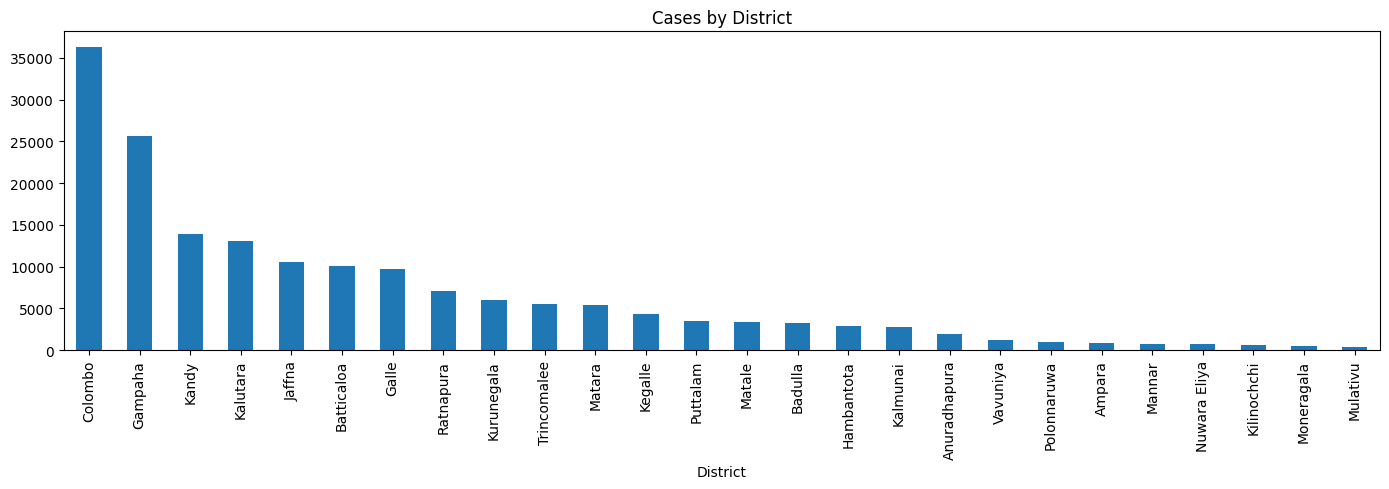

In [15]:
district_totals = df.groupby('District')['Dengue_Cases'].sum().sort_values(ascending=False)
district_totals.plot(kind='bar',figsize=(14,5),title='Cases by District')
plt.tight_layout()
plt.savefig('../outputs/cases-by-district.png')
plt.show()

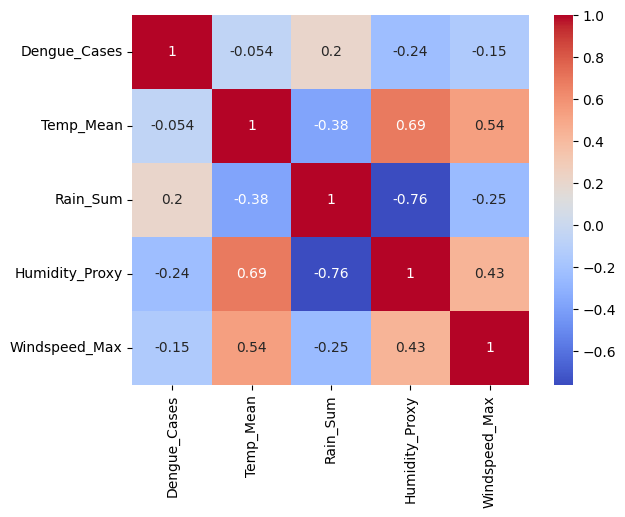

In [19]:
cols = ['Dengue_Cases', 'Temp_Mean','Rain_Sum','Humidity_Proxy','Windspeed_Max']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.savefig('../outputs/correlation-heatmap.png')
plt.show()

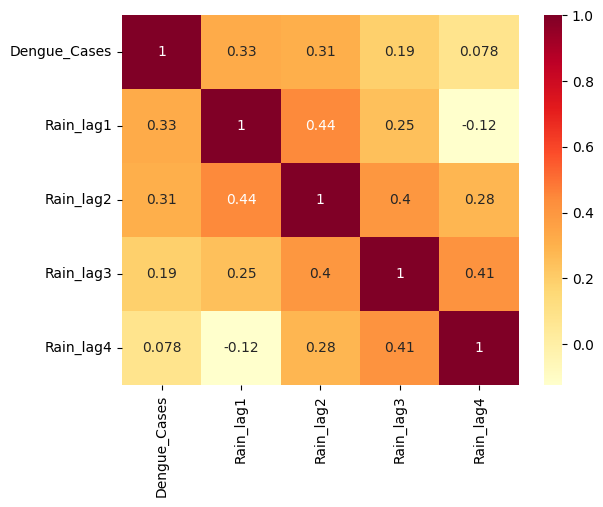

In [21]:
df_sorted =df.sort_values('Date')
for lag in [1,2,3,4]:
    df_sorted[f'Rain_lag{lag}'] = df_sorted.groupby('District')['Rain_Sum'].shift(lag)

lag_cols = ['Dengue_Cases'] + [f'Rain_lag{i}' for i in range(1,5)]
sns.heatmap(df_sorted[lag_cols].corr(),annot=True, cmap = 'YlOrRd')
plt.savefig('../outputs/lag-correlation.png')
plt.show()